# Import Library

In [2]:
import pandas as pd

# Data Loading

In [3]:
kronos_df = pd.read_csv("./data/preprocessing/sept-20-25_clean.csv")
kronos_df.head()

,timestamp,open,high,low,close,volume,amount
0,2020-09-01,17381.8,17533.7,17339.0,17346.9,0.0,0.0
1,2020-09-02,17354.3,17646.9,17325.9,17471.3,0.0,0.0
2,2020-09-03,17475.8,17558.7,17429.3,17489.1,0.0,0.0
3,2020-09-04,17508.4,17542.4,17373.3,17447.7,0.0,0.0
4,2020-09-07,17450.7,17476.5,17399.7,17406.4,0.0,0.0


In [4]:
print(len(kronos_df))
print(kronos_df["timestamp"].min())
print(kronos_df["timestamp"].max())

1305
2020-09-01
2025-09-01


Convert timestamp ke datetime

In [5]:
kronos_df["timestamp"] = pd.to_datetime(
    kronos_df["timestamp"]
)

In [6]:
kronos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1305 entries, 0 to 1304
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  1305 non-null   datetime64[ns]
 1   open       1305 non-null   float64       
 2   high       1305 non-null   float64       
 3   low        1305 non-null   float64       
 4   close      1305 non-null   float64       
 5   volume     1305 non-null   float64       
 6   amount     1305 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 71.5 KB


In [7]:
print(len(kronos_df))
print(kronos_df["timestamp"].min())
print(kronos_df["timestamp"].max())

1305
2020-09-01 00:00:00
2025-09-01 00:00:00


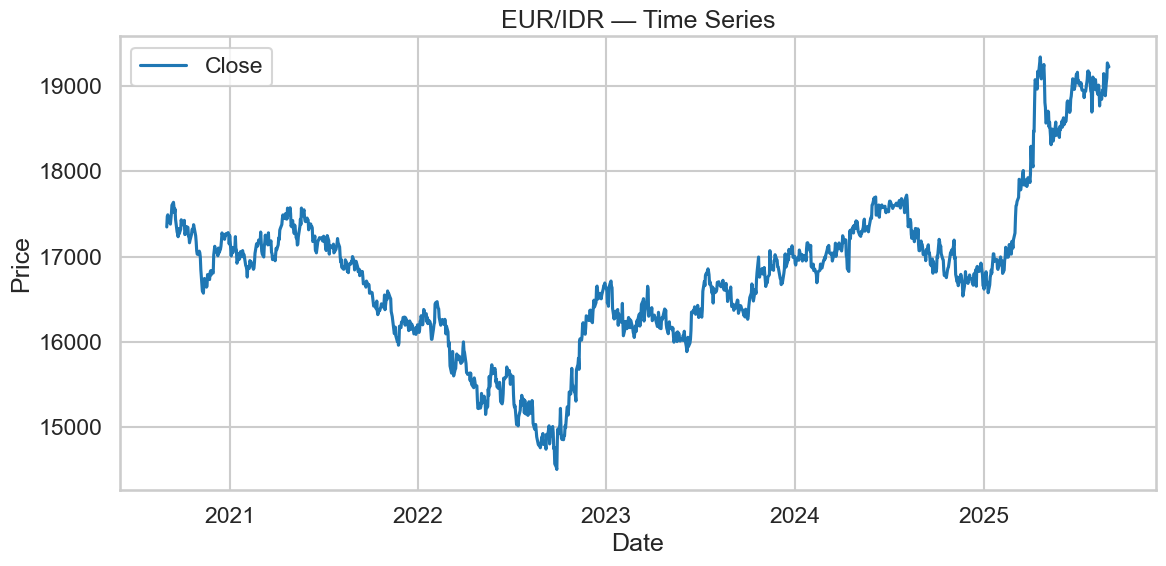

In [8]:
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sns.set(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(kronos_df["timestamp"], kronos_df["close"], label="Close", color="tab:blue")
# ax.plot(kronos_df["timestamp"], kronos_df["open"], label="Open", color="tab:orange", alpha=0.6)
# ax.fill_between(kronos_df["timestamp"], kronos_df["low"], kronos_df["high"], color="gray", alpha=0.2, label="High-Low range")
# ax.plot(kronos_df["timestamp"], kronos_df["close"].rolling(window=20).mean(), label="MA20", linestyle="--", color="tab:green")

ax.set_title("EUR/IDR — Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.tight_layout()
plt.show()

## Cutting data (opsional)

In [18]:
# Ambil 18 bulan terakhir
cutoff = kronos_df["timestamp"].max() - pd.DateOffset(months=3)

df_3y = kronos_df[kronos_df["timestamp"] >= cutoff].copy()

print("Data asli :", len(kronos_df))
print("Data 18 bulan :", len(df_3y))

df_3y.head()

Data asli : 1305
Data 18 bulan : 66


,timestamp,open,high,low,close,volume,amount
1239,2025-06-02,18477.8,18602.2,18476.9,18587.5,0.0,0.0
1240,2025-06-03,18585.9,18645.6,18505.5,18517.7,0.0,0.0
1241,2025-06-04,18518.5,18628.4,18516.9,18599.1,0.0,0.0
1242,2025-06-05,18599.1,18708.9,18553.9,18626.7,0.0,0.0
1243,2025-06-06,18625.9,18647.9,18505.5,18545.4,0.0,0.0


In [19]:
print(len(df_3y))
print(df_3y["timestamp"].min())
print(df_3y["timestamp"].max())

66
2025-06-02 00:00:00
2025-09-01 00:00:00


In [20]:
df_3y.to_csv(
    "./data/preprocessing/sept-20-25_3m.csv",
    index=False
)

# Load model

In [8]:
import sys
sys.path.append("./Kronos")  # sesuaikan dengan lokasi folder Kronos

In [9]:
from model import Kronos, KronosTokenizer, KronosPredictor

In [10]:
# tokenizer = KronosTokenizer.from_pretrained("NeoQuasar/Kronos-Tokenizer-base")
# model = Kronos.from_pretrained("NeoQuasar/Kronos-base")

tokenizer = KronosTokenizer.from_pretrained("./Kronos/finetuned/eur_idr_daily/tokenizer/best_model")
model = Kronos.from_pretrained("./Kronos/finetuned/eur_idr_daily/basemodel/best_model")

Loading weights from local directory
Loading weights from local directory


In [11]:
predictor = KronosPredictor(model, tokenizer, max_context=512)

# inference

In [13]:
x_df = kronos_df[["open", "high", "low", "close"]]
x_timestamp = kronos_df["timestamp"]

In [14]:
print(kronos_df["timestamp"].min())
print(kronos_df["timestamp"].max())


2021-01-01 00:00:00
2026-01-30 00:00:00


In [15]:
import pandas as pd

prediction_length = 30

last_date = kronos_df["timestamp"].max()
future_dates = pd.Series(
    pd.date_range(
        start=last_date + pd.offsets.BDay(1),
        periods=prediction_length,
        freq="B"
    )
)

In [16]:
forecast = predictor.predict(
    df=x_df,
    x_timestamp=x_timestamp,
    y_timestamp=future_dates,
    pred_len=prediction_length,
    T=0.7,
    top_p=0.9,
    sample_count=20,
    verbose=True
)

100%|██████████| 30/30 [13:55<00:00, 27.84s/it]


In [17]:
forecast

,open,high,low,close,volume,amount
2026-02-02,16974.660156,17261.066406,15761.481445,16412.244141,8.201300e-06,5.372940e-06
2026-02-03,16547.208984,16568.082031,15970.456055,16259.891602,6.102369e-06,4.623325e-06
2026-02-04,16277.671875,16372.326172,15934.314453,16244.937500,7.300042e-06,6.449923e-06
2026-02-05,16246.042969,16355.810547,15917.189453,16236.866211,2.045090e-06,1.338342e-06
2026-02-06,16291.432617,16351.794922,16150.386719,16291.340820,4.670904e-06,4.576216e-06
2026-02-09,16389.066406,16480.947266,16138.694336,16332.207031,4.195816e-06,3.857886e-06
2026-02-10,16402.972656,16503.873047,16119.776367,16370.229492,5.481912e-06,4.975853e-06
2026-02-11,16302.441406,16464.509766,16097.800781,16368.120117,4.058276e-06,3.222603e-06
2026-02-12,16369.240234,16430.451172,16196.588867,16326.687500,5.872855e-07,4.002093e-07
2026-02-13,16351.676758,16411.595703,16167.987305,16327.407227,9.618816e-07,7.646579e-07
